# 08 — Full MagSIMS workflow

This notebook demonstrates an end-to-end analysis:

```text
main spectrum file
→ peak detection
→ isotope assignment
→ bin generation
→ raw FPD image loading
→ mass-filtered ion images
→ processed FPD image comparison
```

In [6]:
%load_ext autoreload
%autoreload 2

from pathlib import Path
import pandas as pd

from pymagsims import spectrum
from pymagsims.spectrum import Spectrum
from pymagsims.raw_image import SIMSRawImage
from pymagsims.image import SIMSImage
from pymagsims.isotopes import load_builtin_isotopes
from pymagsims.plotting import plot_ion_image_grid

DATA = Path("../data")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 1. Load spectrum and identify peaks

In [7]:
spec = Spectrum.from_main_analysis_file(DATA / "FPD_01_2604281458290.csv")
isotopes = load_builtin_isotopes()

assignments = spec.assign_peaks(
    isotope_table=isotopes,
    tolerance=0.2,
    prominence=100,
    distance=5,
)

bins = spec.create_bins_from_assignments(
    assignments,
    width=0.3,
)

display(assignments.head(20))
display(bins.head(20))

,measured_mass,intensity,element,isotope,exact_mass,abundance,mass_error,abs_mass_error
0,12.142001,600.0,C,12C,12.000000,98.930,0.142001,0.142001
1,13.196964,254.0,C,13C,13.003355,1.070,0.193609,0.193609
2,56.742039,4005.0,Fe,57Fe,56.935393,2.119,-0.193354,0.193354
3,56.830325,2284.0,Fe,57Fe,56.935393,2.119,-0.105068,0.105068
4,56.918679,867.0,Fe,57Fe,56.935393,2.119,-0.016714,0.016714
5,62.744836,16600.0,Cu,63Cu,62.929598,69.150,-0.184762,0.184762
6,62.868545,8321.0,Cu,63Cu,62.929598,69.150,-0.061053,0.061053
7,62.992374,2749.0,Cu,63Cu,62.929598,69.150,0.062776,0.062776
8,63.737871,4989.0,Zn,64Zn,63.929142,49.170,-0.191271,0.191271
9,63.831363,4716.0,Zn,64Zn,63.929142,49.170,-0.097779,0.097779


,label,element,isotope,center_mass,exact_mass,mass_error,mass_min,mass_max,integrated_intensity,max_intensity,n_points
0,12C,C,12C,12.142001,12.000000,0.142001,11.917001,12.367001,8839.0,600.0,65
1,13C,C,13C,13.196964,13.003355,0.193609,12.971964,13.421964,4016.0,254.0,62
2,57Fe,Fe,57Fe,56.830359,56.935393,-0.193354,56.517039,57.143679,66323.0,4005.0,43
3,63Cu,Cu,63Cu,62.868605,62.929598,-0.184762,62.519836,63.217374,289188.0,16600.0,45
4,64Zn,Zn,64Zn,63.831396,63.929142,-0.191271,63.512871,64.149922,87387.0,4989.0,41
5,65Cu,Cu,65Cu,64.911448,64.927790,-0.157796,64.544994,65.277902,130337.0,6953.0,47
6,66Zn,Zn,66Zn,65.952866,65.926034,-0.115737,65.585297,66.320435,48054.0,2517.0,47
7,69Ga,Ga,69Ga,68.939866,68.925574,-0.123333,68.577241,69.302492,1917634.0,99392.0,44
8,71Ga,Ga,71Ga,70.986594,70.924703,0.012611,70.712314,71.260875,9311.0,396.0,33


## 2. Generate raw-event ion images

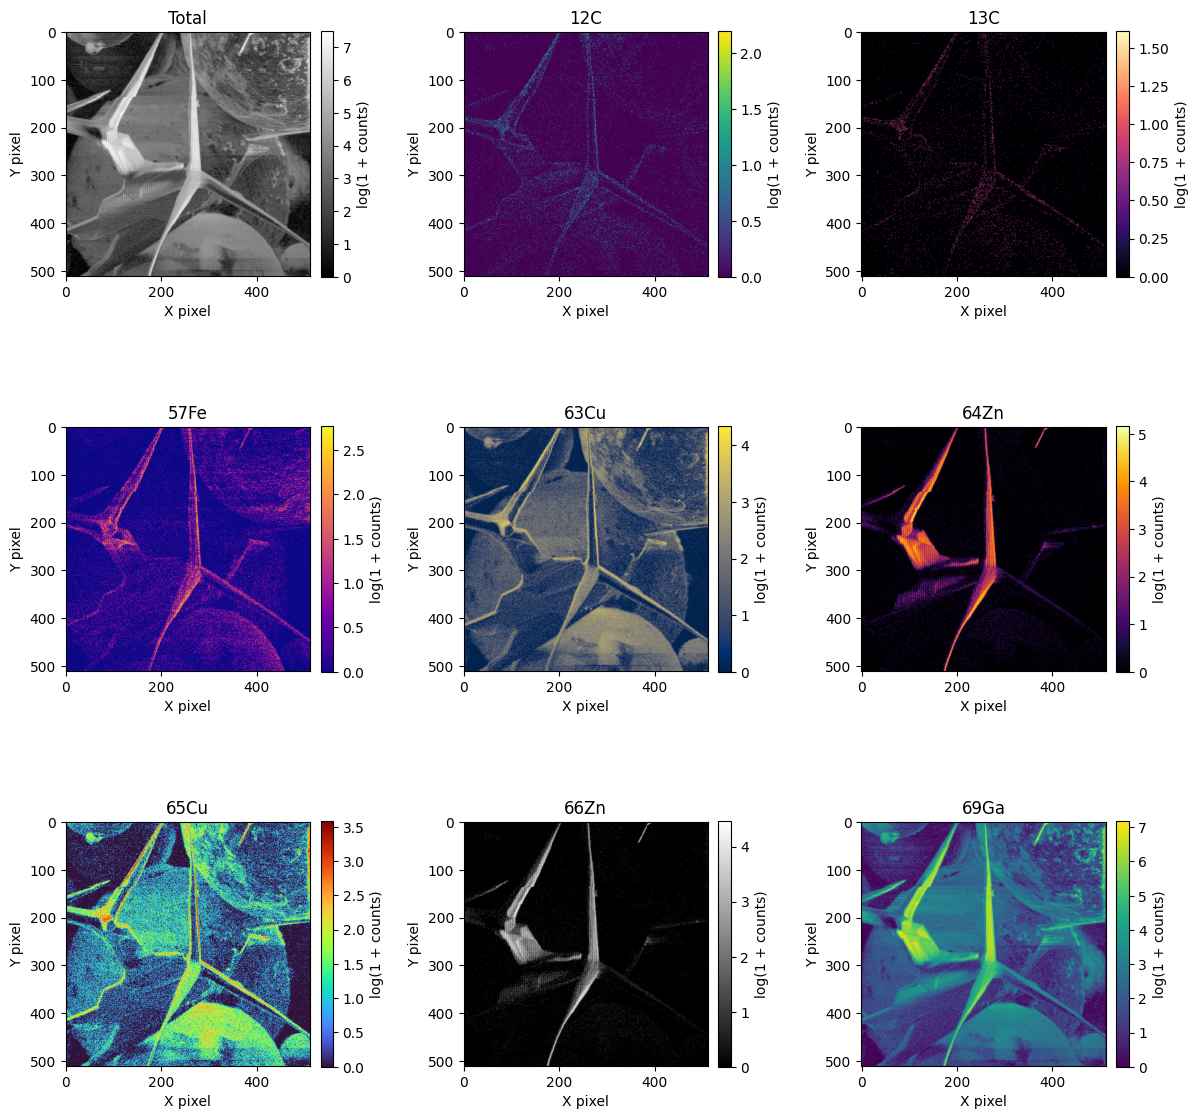

In [4]:
raw = SIMSRawImage.from_fpd_raw(DATA / "FPD_image2.raw")

# Keep the first few bins for a compact demo.
images = raw.images_from_bins(
    spectrum=spec,
    bins=bins.head(8),
    include_total=True,
)

plot_ion_image_grid(
    images,
    log=True,
    ncols=3,
    cmaps=["gray", "viridis", "magma", "plasma", "cividis", "inferno", "turbo"],
);

## 3. Compare with processed FPD CSV export

['Total']


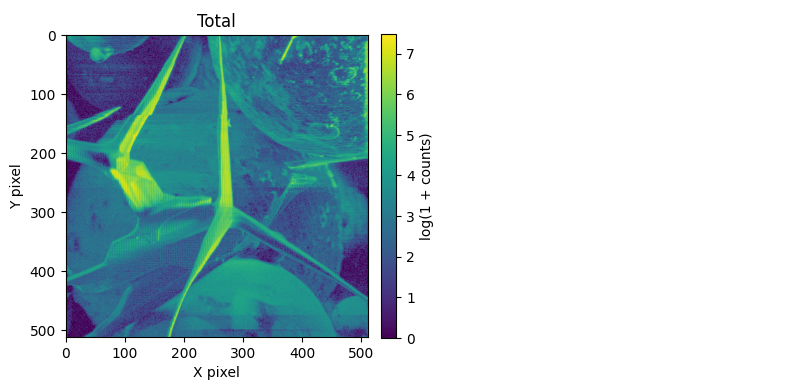

In [5]:
processed = SIMSImage.from_fpd_csv(DATA / "FPD_image2.csv")

print(processed.labels())

plot_ion_image_grid(
    processed.images,
    log=True,
    ncols=2,
);

## Interpretation notes

- The raw-event pathway gives maximum flexibility because bins can be changed after acquisition.
- The processed FPD CSV pathway loads images that were already integrated/exported by the instrument software.
- Peak assignment remains tentative unless supported by sample context, isotope patterns, and possible cluster-ion analysis.